<a href="https://colab.research.google.com/github/RishikaBhawsingka/NLP-ML-project/blob/main/6_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# ===============================
# Project Directories
# ===============================

BASE_DIR = "/content/drive/MyDrive/HumanBehaviourSimulator"

CLEAN_DIR = os.path.join(BASE_DIR, "cleaned_data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
REPORT_DIR = os.path.join(BASE_DIR, "reports")
RF_PLOTS_DIR = os.path.join(BASE_DIR, "plots", "Random_Forest")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(RF_PLOTS_DIR, exist_ok=True)

print("✅ Project Loaded Successfully")

Mounted at /content/drive
✅ Project Loaded Successfully


In [ ]:
train = pd.read_csv(
    os.path.join(CLEAN_DIR, "train_clean.csv"),
    keep_default_na=False
)

validation = pd.read_csv(
    os.path.join(CLEAN_DIR, "validation_clean.csv"),
    keep_default_na=False
)

test = pd.read_csv(
    os.path.join(CLEAN_DIR, "test_clean.csv"),
    keep_default_na=False
)

print(train.shape)
print(validation.shape)
print(test.shape)

(43410, 5)
(5426, 5)
(5427, 5)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(train["clean_text"])
X_validation = tfidf.transform(validation["clean_text"])
X_test = tfidf.transform(test["clean_text"])

y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]

print(X_train.shape)
print(X_validation.shape)
print(X_test.shape)

(43410, 5000)
(5426, 5000)
(5427, 5000)


In [ ]:
joblib.dump(
    tfidf,
    os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl")
)

print("✅ TF-IDF Vectorizer Saved")

✅ TF-IDF Vectorizer Saved


In [ ]:
#exp 1 no. of trees default 100
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest Model Trained")

✅ Random Forest Model Trained


In [ ]:
#exp 2 inc no. of trees to 300
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest (300 Trees) Trained")

✅ Random Forest (300 Trees) Trained


In [ ]:
#exp 3 max_depth
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest (300 Trees, Depth=30) Trained")

✅ Random Forest (300 Trees, Depth=30) Trained


In [ ]:
# Predict on validation set
y_validation_pred = rf_model.predict(X_validation)

print("✅ Validation Prediction Completed")

✅ Validation Prediction Completed


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

validation_accuracy = accuracy_score(y_validation, y_validation_pred)

validation_precision = precision_score(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0
)

validation_recall = recall_score(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0
)

validation_f1 = f1_score(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0
)

print("="*50)
print("📊 Random Forest - Validation Results")
print("="*50)

print(f"Accuracy : {validation_accuracy:.4f}")
print(f"Precision: {validation_precision:.4f}")
print(f"Recall   : {validation_recall:.4f}")
print(f"F1 Score : {validation_f1:.4f}")

📊 Random Forest - Validation Results
Accuracy : 0.4196
Precision: 0.4488
Recall   : 0.4196
F1 Score : 0.3080


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# Predict on test dataset
y_test_pred = rf_model.predict(X_test)

print("✅ Test Prediction Completed")

✅ Test Prediction Completed


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

print("="*55)
print("📊 Random Forest - Test Results")
print("="*55)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

📊 Random Forest - Test Results
Accuracy : 0.5217
Precision: 0.5034
Recall   : 0.5217
F1 Score : 0.4677


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.59      0.65      0.62       504
           1       0.72      0.82      0.77       252
           2       0.47      0.36      0.41       197
           3       0.48      0.13      0.20       286
           4       0.39      0.16      0.23       318
           5       0.37      0.14      0.20       114
           6       0.55      0.16      0.25       139
           7       0.28      0.03      0.06       233
           8       0.62      0.22      0.32        74
           9       0.39      0.09      0.14       127
          10       0.24      0.05      0.08       220
          11       0.56      0.38      0.45        84
          12       0.44      0.13      0.21        30
          13       0.58      0.30      0.39        84
          14       0.64      0.53      0.58        74
          15       0.81      0.85      0.83       288
          16       0.00      0.00      0.00         6
          17       0.49    

In [ ]:
from sklearn.metrics import confusion_matrix

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print(cm_test.shape)

(28, 28)


In [ ]:
import joblib
import os

joblib.dump(
    rf_model,
    os.path.join(MODEL_DIR, "random_forest_300_trees.pkl")
)

print("✅ Random Forest model saved successfully!")

✅ Random Forest model saved successfully!


In [ ]:
!pip install python-docx

In [ ]:

from docx import Document
from docx.shared import Pt
import os

BASE_DIR = "/content/drive/MyDrive/HumanBehaviourSimulator"

REPORT_DIR = os.path.join(BASE_DIR, "reports")
# ===================================
# Create Report
# ===================================

doc = Document()

title = doc.add_heading("Experiment 03: Random Forest Report", level=1)
title.runs[0].font.size = Pt(20)

doc.add_paragraph(
    "Model: Random Forest Classifier\n"
    "Dataset: GoEmotions\n"
    "Feature Engineering: TF-IDF (5000 Features)\n"
    "Objective: Emotion Classification"
)

# ------------------------------------------------
# Experiment Objective
# ------------------------------------------------

doc.add_heading("1. Objective", level=2)

doc.add_paragraph(
    "The objective of this experiment was to train and evaluate a Random Forest "
    "classifier for multi-class emotion classification. Hyperparameter tuning was "
    "performed to improve the model performance while maintaining good generalization."
)

# ------------------------------------------------
# Experiments
# ------------------------------------------------

doc.add_heading("2. Hyperparameter Tuning Experiments", level=2)

table = doc.add_table(rows=1, cols=6)
table.style = "Table Grid"

hdr = table.rows[0].cells
hdr[0].text = "Experiment"
hdr[1].text = "Configuration"
hdr[2].text = "Accuracy"
hdr[3].text = "Precision"
hdr[4].text = "Recall"
hdr[5].text = "F1 Score"

experiments = [

["Exp 1",
 "Default (100 Trees)",
 "0.5158",
 "0.4954",
 "0.5158",
 "0.4626"],

["Exp 2",
 "300 Trees",
 "0.5186",
 "0.4969",
 "0.5186",
 "0.4651"],

["Exp 3",
 "100 Trees + max_depth=30",
 "0.4196",
 "0.4488",
 "0.4196",
 "0.3080"]

]

for exp in experiments:
    row = table.add_row().cells
    for i in range(6):
        row[i].text = exp[i]

# ------------------------------------------------
# Best Model
# ------------------------------------------------

doc.add_heading("3. Selected Model", level=2)

doc.add_paragraph(
    "The Random Forest model with 300 decision trees produced the best "
    "validation performance and was therefore selected as the final model."
)

doc.add_paragraph(
    "Final Configuration:\n"
    "• n_estimators = 300\n"
    "• random_state = 42\n"
    "• n_jobs = -1"
)

# ------------------------------------------------
# Validation Results
# ------------------------------------------------

doc.add_heading("4. Validation Results", level=2)

doc.add_paragraph(
    "Accuracy : 0.5186\n"
    "Precision: 0.4969\n"
    "Recall   : 0.5186\n"
    "F1 Score : 0.4651"
)

# ------------------------------------------------
# Test Results
# ------------------------------------------------

doc.add_heading("5. Test Results", level=2)

doc.add_paragraph(
    "Accuracy : 0.5217\n"
    "Precision: 0.5034\n"
    "Recall   : 0.5217\n"
    "F1 Score : 0.4677"
)

# ------------------------------------------------
# Observations
# ------------------------------------------------

doc.add_heading("6. Observations", level=2)

doc.add_paragraph(
    "• Three Random Forest configurations were evaluated.\n"
    "• Increasing the number of trees from 100 to 300 slightly improved the model performance.\n"
    "• Restricting the maximum tree depth to 30 caused a significant reduction in performance, indicating underfitting.\n"
    "• The selected model generalized well because the validation and test results were very similar.\n"
    "• Although the 300-tree model required additional training time, it achieved the highest overall performance."
)

# ------------------------------------------------
# Comparison
# ------------------------------------------------

doc.add_heading("7. Comparison with Previous Models", level=2)

table2 = doc.add_table(rows=1, cols=3)
table2.style = "Table Grid"

hdr = table2.rows[0].cells
hdr[0].text = "Model"
hdr[1].text = "Accuracy"
hdr[2].text = "F1 Score"

models = [

["Logistic Regression","0.5126","0.4562"],
["Naive Bayes","0.4070","0.3203"],
["Random Forest","0.5217","0.4677"]

]

for model in models:
    row = table2.add_row().cells
    for i in range(3):
        row[i].text = model[i]

# ------------------------------------------------
# Conclusion
# ------------------------------------------------

doc.add_heading("8. Conclusion", level=2)

doc.add_paragraph(
    "The Random Forest classifier produced the best performance among all "
    "classical machine learning models evaluated in this project. Hyperparameter "
    "tuning demonstrated that increasing the number of trees improved the "
    "classification performance, whereas limiting the tree depth reduced model "
    "effectiveness. The final model achieved a test accuracy of 52.17% with an "
    "F1-score of 46.77%, outperforming both Logistic Regression and Naive Bayes "
    "on the GoEmotions dataset."
)

# ------------------------------------------------
# Future Work
# ------------------------------------------------

doc.add_heading("9. Future Work", level=2)

doc.add_paragraph(
    "The next phase of the project will focus on implementing a transformer-based "
    "BERT model for emotion classification. The performance of BERT will be "
    "compared against the three classical machine learning models to determine "
    "the most effective approach for the Human Behaviour Simulator."
)

# ------------------------------------------------
# Save Report
# ------------------------------------------------

report_path = os.path.join(
    REPORT_DIR,
    "Experiment_03_Random_Forest_Report.docx"
)

doc.save(report_path)

print("✅ Random Forest report generated successfully!")
print(report_path)

✅ Random Forest report generated successfully!
/content/drive/MyDrive/HumanBehaviourSimulator/reports/Experiment_03_Random_Forest_Report.docx


<Figure size 1400x1400 with 0 Axes>

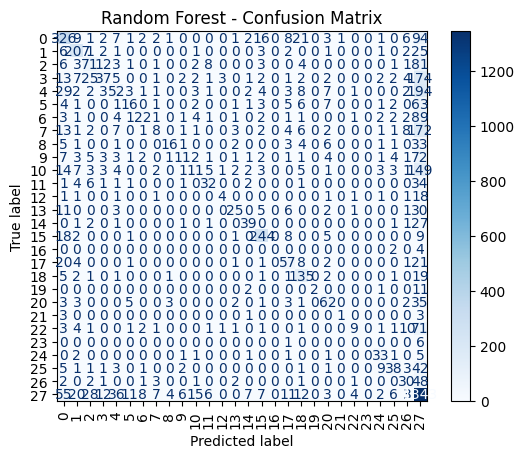

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(14,14))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Random Forest - Confusion Matrix")

plt.savefig(
    os.path.join(
        RF_PLOTS_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

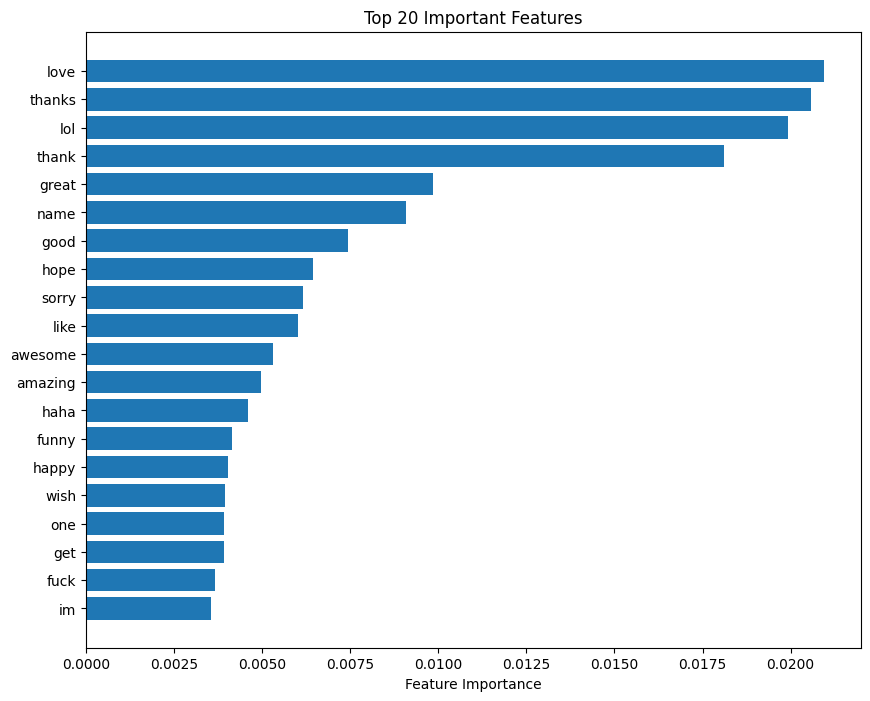

In [ ]:
import numpy as np

feature_names = tfidf.get_feature_names_out()

importances = rf_model.feature_importances_

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10,8))

plt.barh(
    feature_names[indices],
    importances[indices]
)

plt.title("Top 20 Important Features")

plt.xlabel("Feature Importance")

plt.savefig(
    os.path.join(
        RF_PLOTS_DIR,
        "feature_importance_top20.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/content/drive/MyDrive/HumanBehaviourSimulator/plots


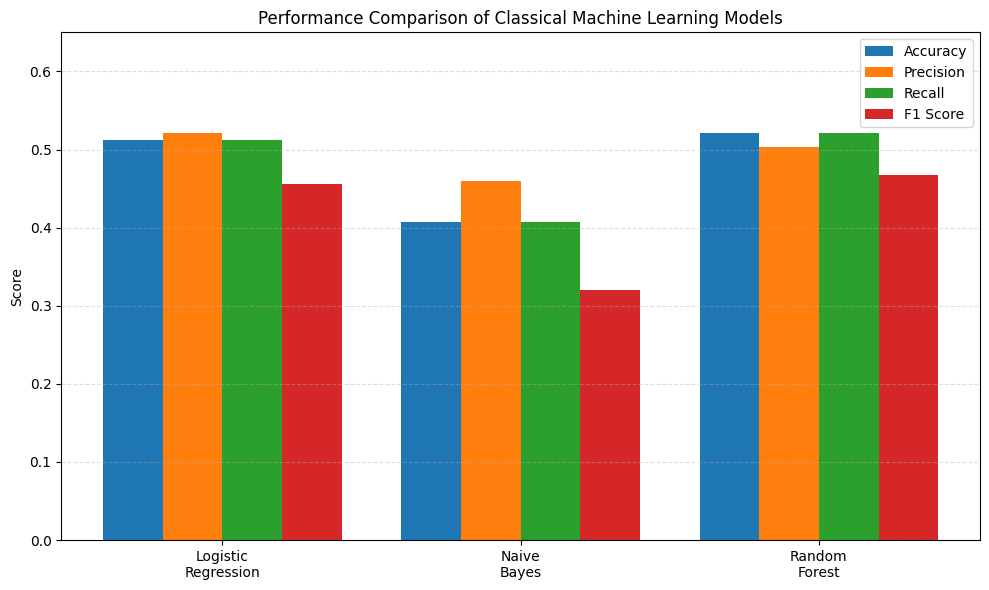

✅ Comparison plot saved successfully!
/content/drive/MyDrive/HumanBehaviourSimulator/plots/Model_Comparison.png


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

PLOTS_DIR = os.path.join(BASE_DIR, "plots")

print(PLOTS_DIR)

# ===========================
# Save Path
# ===========================

comparison_plot_path = os.path.join(
    PLOTS_DIR,
    "Model_Comparison.png"
)

# ===========================
# Data
# ===========================

models = [
    "Logistic\nRegression",
    "Naive\nBayes",
    "Random\nForest"
]

accuracy = [0.5126, 0.4070, 0.5217]
precision = [0.5213, 0.4592, 0.5034]
recall = [0.5126, 0.4070, 0.5217]
f1 = [0.4562, 0.3203, 0.4677]

# ===========================
# Plot
# ===========================

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1 Score")

plt.xticks(x, models)
plt.ylim(0, 0.65)

plt.ylabel("Score")
plt.title("Performance Comparison of Classical Machine Learning Models")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# ===========================
# Save
# ===========================

plt.savefig(
    comparison_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Comparison plot saved successfully!")
print(comparison_plot_path)

In [ ]:
from docx import Document
import os

# Existing project documentation
project_doc = os.path.join(
    BASE_DIR,
    "Project_Documentation.docx"
)

doc = Document(project_doc)

# ==========================================
# Notebook 6 Update
# ==========================================

doc.add_heading("✅ Notebook 6: Random Forest (Completed)", level=2)

doc.add_paragraph(
    "Objective:\n"
    "Developed and evaluated a Random Forest classifier for multi-class "
    "emotion classification using TF-IDF features from the GoEmotions dataset."
)

doc.add_paragraph(
    "Work Completed:\n"
    "• Trained baseline Random Forest model.\n"
    "• Performed hyperparameter tuning (100 trees, 300 trees and max_depth=30).\n"
    "• Selected the best-performing model (300 trees).\n"
    "• Evaluated on validation and test datasets.\n"
    "• Generated confusion matrix and feature importance visualizations.\n"
    "• Saved trained model, plots and experiment report."
)

doc.add_paragraph(
    "Hyperparameter Tuning Summary:\n"
    "• Exp 1: Default (100 Trees) → Validation Accuracy: 51.58%\n"
    "• Exp 2: 300 Trees → Validation Accuracy: 51.86% (Selected)\n"
    "• Exp 3: max_depth=30 → Validation Accuracy: 41.96% (Underfitting)"
)

doc.add_paragraph(
    "Final Test Results:\n"
    "Accuracy : 52.17%\n"
    "Precision: 50.34%\n"
    "Recall   : 52.17%\n"
    "F1 Score : 46.77%"
)

doc.add_paragraph(
    "Conclusion:\n"
    "Random Forest achieved the best overall performance among all classical "
    "machine learning models evaluated in this project. Increasing the number "
    "of trees slightly improved performance, while limiting tree depth reduced "
    "classification accuracy due to underfitting."
)

# ==========================================
# Update Upcoming Work
# ==========================================

doc.add_heading("🚀 Updated Upcoming Work", level=1)

doc.add_heading("Notebook 7: BERT Transformer", level=2)

doc.add_paragraph(
    "Planned Tasks:\n"
    "• Fine-tune a pre-trained BERT model on the GoEmotions dataset.\n"
    "• Tokenize text using the BERT tokenizer.\n"
    "• Train and validate the transformer model.\n"
    "• Evaluate on the unseen test dataset.\n"
    "• Compare BERT with Logistic Regression, Naive Bayes and Random Forest.\n"
    "• Generate visualizations and experiment report.\n"
    "• Select the overall best-performing model for the Human Behaviour Simulator."
)

doc.save(project_doc)

print("✅ Project Documentation updated successfully!")
print(project_doc)

✅ Project Documentation updated successfully!
/content/drive/MyDrive/HumanBehaviourSimulator/Project_Documentation.docx
